In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import statistics
import numpy as np
pathToFolder = ""
plt.rcParams.update({'font.size': 10})

results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

all_throughput_results = []
all_median_fairness_results = []
all_max_fairness_results = []
all_time_results = []
all_first2_results = []

util_with_udp_array = []

labels = []

fifo_or_cebinae = ""

In [2]:
def plot():
    # throughput calculation
    time_1 = []
    time_2 = []
    time_3 = []
    time_4 = []
    throughput_array_1 = []
    throughput_array_2 = []
    throughput_array_3 = []
    throughput_array_4  = []
    throughput_array_udp = []
    packet_drop_1 = []
    packet_drop_2 = []
    packet_drop_3 = []
    packet_drop_4 = []
            
    # if any file is does not have entries that go until [duration--30s], print error and change experiments    
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        if (last_time_of_file < 29):
            print("error in file 0-0-1.out")
            print(last_time_of_file)
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        last_line_of_file = rf.readlines()[-1]
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-2.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-3.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-4.out")
            print(last_time_of_file)

    ################################################ throughput ###########################################################
    # # # # # # # # # # # # # # # # # # # # # # # #  four flows # # # # # # # # # # # # # # # # # # # # # # # # # # #

    time_total_throughput = []
    total_throughput_array = []

    prev_recorded_time: float = 0
    total_time: float = 0
    total_size: float = 0
    time_index = 0.1
    total_throughput_array = []

    # total throughput

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full-throughput-sorted.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_total_throughput.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                total_throughput_array.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time


    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now

    # throughput 1
    prev_seq_number: float = 0
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_1.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                throughput_array_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    # throughput 2

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            # bookmark first_index_in_array_from_data_2 for throughput calculations later (measuring throughput of first second)
            first_index_in_array_from_data_2 = first_index_in_array_from_data
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_2.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    inserted_all_new_indices = False
    # compare time_index (0.1) to first time in file 0-0-2 (time when first packet is received)
    while (time_index < first_index_in_array_from_data):
        # insert time_index in time array to fill time (to match length of time_1)--match flow start time
        time_2.insert(index, round(time_index, 2))
        throughput_array_2.insert(index, 0)
        index += 1
        time_index += 0.1
        # when time_index has reached the first time in the file (when flow starts), stop inserting new values
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    # if flow stops just before 29.9 (between 19 and 29.9--see above for error for flow stopping before 19s)
    # append time_index and throughput = 0 until array lengths are the same
    last_time_index = time_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_2.append(round(last_time_index, 2))
        throughput_array_2.append(0)


    # throughput 3

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_3.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_3.insert(index, round(time_index, 2))
        throughput_array_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_3.append(round(last_time_index, 2))
        throughput_array_3.append(0)

    # throughput 4

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_4.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_4.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_4.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_4.insert(index, round(time_index, 2))
        throughput_array_4.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_4[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_4.append(round(last_time_index, 2))
        throughput_array_4.append(0)
  
    # udp
        # udp
    time_udp_1 = []
    throughput_array_udp_1 = []
    time_udp_2 = []
    throughput_array_udp_2 = []
    time_udp_3 = []
    throughput_array_udp_3 = []
        
    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_1.insert(index, round(time_index, 2))
        throughput_array_udp_1.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_1[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_1.append(round(last_time_index, 2))
        throughput_array_udp_1.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_2.insert(index, round(time_index, 2))
        throughput_array_udp_2.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_2.append(round(last_time_index, 2))
        throughput_array_udp_2.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_3.insert(index, round(time_index, 2))
        throughput_array_udp_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_3.append(round(last_time_index, 2))
        throughput_array_udp_3.append(0)
        
        
#      # udp
#     time_udp = []
#     throughput_array_udp = []
        
#     prev_time = 0
#     total_time = 0
#     total_size = 0
#     prev_recorded_time = 0
#     last_time = 0
#     time_index = 0.1 # not used right now
#     first_index_in_array_from_data = 0
#     # used to calculate where time_index should be
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
#             first_index_in_array_from_data = time_index
#             break
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             # current time
#             total_time = float(line.split(" IP", 1)[0])

#             # current size
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28
#             size = size * 8
#             total_size += size

#             if (total_time >= time_index):

#                 # add 100 ms interval to time array
#                 time_udp.append(round(time_index, 2))

#                 # add throughput to throughput array
#                 throughput = (total_size - size) / 0.1 # throughput (size / time)

#                 throughput_array_udp.append(throughput / 1000000) # convert bps to Mbps

#                 time_index += 0.1
#                 total_size = size
#                 prev_recorded_time = last_time
#             last_time = total_time

#         time_index = 0.1
#     index = 0
#     while (time_index < first_index_in_array_from_data):
#         time_udp.insert(index, round(time_index, 2))
#         throughput_array_udp.insert(index, 0)
#         index += 1
#         time_index += 0.1
#         if (time_index == first_index_in_array_from_data):
#             inserted_all_new_indices = True

#     last_time_index = time_udp[-1]
#     while (last_time_index < last_time_of_file):
#         last_time_index += 0.1
#         time_udp.append(round(last_time_index, 2))
#         throughput_array_udp.append(0)

#     ############################### queue #######################################################
#     line_number = 0
#     prev_sign = "-"
#     duplicate_line = 0 

#     dropped_packets = [] # array that contains all times where packets were dropped
#     dropped_packets_markers = []
#     prev_time = 0

#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full_sorted_duplicates_TCP.out', 'r') as file:
#         for line in file:
#             line_number += 1
#             adjusted_size = 0

#             sign = line.split(" ", 1)[0]
#             temp_time = line.split(" IP", 1)[0]
#             time = float(temp_time.split(" ")[1])

#             # find size to add to queue
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28

#             size = size * 8
#             adjusted_size += size
#             # if it's TCP traffic, check that signs do not match
#             if (not line.__contains__("UDP")):
#                 if (prev_sign == "-" and sign != "+"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)
#                 elif (prev_sign == "+" and sign != "-"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)

#             prev_sign = sign
#             prev_line = line
#             prev_time = time

    # total with all udp

    total_throughput_with_all_udp = []
        
    for index in range (0, len(time_1)):
        total_throughput_with_all_udp.append(total_throughput_array[index] + throughput_array_udp_1[index] + throughput_array_udp_2[index] + throughput_array_udp_3[index])

            
    # creating new np arrays so that slice operation can be performed
    np_array_1 = np.array(throughput_array_1)
    np_array_2 = np.array(throughput_array_2)
    np_array_3 = np.array(throughput_array_3)
    np_array_4 = np.array(throughput_array_4)  
#     np_throughput_array_udp = np.array(throughput_array_udp)

    # calculate ratio between max/min of four flows using slicing window
    for index in range(40, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])
        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0

    # find utilization from 6s--> (total throughput)
    utilization_array_total_throughput = []
    for index in range (60, len(time_1)):  
#         utilization_array_total_throughput.append(np_throughput_array_udp[index] + throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
        utilization_array_total_throughput.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_after_60_total_throughput = statistics.mean(utilization_array_total_throughput)
#     print("utilization 6s--> (total throughput): " + str(statistics.mean(utilization_array_total_throughput)))

    # find utilization of last 5 seconds
    utilization_array = []
    for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
        utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_last5 = statistics.mean(utilization_array)
#     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))

#     utilization_array_with_udp = []
#     for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array_with_udp.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
# #         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
#     util_with_udp_last5 = statistics.mean(utilization_array_with_udp)
# #     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))
#     util_with_udp_array.append(util_with_udp_last5)


    # calculate throughput of first flow for 0-2s
    utilization_array_0_2s = []
    for index in range (0, time_1.index(round(first_index_in_array_from_data_2, 1))):
        utilization_array_0_2s.append(throughput_array_1[index])
        util_first2 = statistics.mean(utilization_array_0_2s)

    ratio_array = []

    # calculate ratio between max/min of four flows using slicing window for 15s-18s
    for index in range(len(time_1) - 50, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        if ((index + 20) <= len(time_1)): # ensure that there is enough room for slicing window (15-18s)
            throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])

        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0
            print("Replace this iteration: ", iteration)
        ratio_array.append(ratio)

    ratio_array_np = np.array(ratio_array)

#     results_throughput.append(statistics.mean(utilization_array_with_udp))
    results_throughput.append(statistics.mean(utilization_array))
    results_median_fairness.append(statistics.median(ratio_array))
    results_max_fairness.append(ratio_array_np.max())
    results_first2.append(util_first2)

    # raw fifo only: assigning Raw FIFO median fairness ratio to be used as constraint
    if (raw_fifo):
        rawFIFOMedianFairnessRatio = statistics.median(ratio_array)
    
#     print("median ratio:", statistics.median(ratio_array))
#     print("max ratio: ", ratio_array_np.max())
#     print("udp:", statistics.median(throughput_array_udp))
    
    if (show_plot):
            ################################### plot throughput--and dropped packets (Mbps) #########################################################
        plt.plot(time_1, throughput_array_1, label="Flow 1")
        plt.plot(time_2, throughput_array_2, label="Flow 2")
        plt.plot(time_3, throughput_array_3, label="Flow 3")
        plt.plot(time_4, throughput_array_4, label="Flow 4")
        plt.plot(time_udp_1, throughput_array_udp_1, label="UDP", color='hotpink', alpha=0.5)
        plt.plot(time_udp_2, throughput_array_udp_2, label="UDP", color='gold', alpha=0.5)
        plt.plot(time_udp_3, throughput_array_udp_3, label="UDP", color='indigo', alpha=0.5)
        plt.plot(time_total_throughput, total_throughput_array, label="Total Throughput", color='black')
        plt.plot(time_total_throughput, total_throughput_with_all_udp, color='grey')
        plt.plot(packet_drop_1, np.full((len(packet_drop_1)), -3, dtype=int), 'bo') # dropped packets
        plt.plot(packet_drop_2, np.full((len(packet_drop_2)), 3, dtype=int), 'o', color='orange') # dropped packets
        plt.plot(packet_drop_3, np.full((len(packet_drop_3)), 0, dtype=int), 'go') # dropped packets
        plt.plot(packet_drop_4, np.full((len(packet_drop_4)), 6, dtype=int), 'ro') # dropped packets

#     plt.legend(['Flow 1', 'Flow 2', 'Flow 3', 'Flow 4', 'Total Throughput'], loc='upper left', bbox_to_anchor=(1, 1))
        plt.xlabel("Time (s)")
        plt.ylabel("Throughput (Mbps)")
        yticks = np.arange(0, 110, 10)
        plt.yticks(yticks)
    #     plt.title("Tax Constant: " + taxConstant + " Median Fairness: " + str(round(median_fairness, 2)))
        plt.show()
        print("median ratio:", statistics.median(ratio_array))

    return results_throughput, results_median_fairness, results_max_fairness, results_first2

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.07516928
median fairness: 2.864992358916531
max fairness: 3.2299677971009104


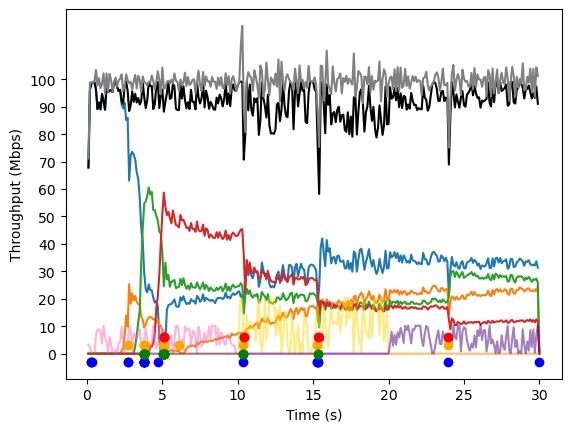

median ratio: 2.80813959355008


([94.1701632,
  94.8939264,
  93.422592,
  93.4868736,
  94.3534848,
  93.660672,
  95.0629632,
  93.1416576,
  95.0320128,
  93.5273472,
  94.8939264],
 [2.010195469555075,
  2.80813959355008,
  4.078132344773644,
  2.9218451242829824,
  2.6994266994266995,
  4.149102073901635,
  4.724430626311058,
  2.5299376515476,
  1.7230871149387215,
  6.518687329079308,
  2.80813959355008],
 [2.102032682343563,
  2.8922436231129622,
  4.671740569159497,
  3.1273699562469615,
  2.8032454361054766,
  4.727150537634409,
  5.178694158075602,
  3.3325656379548594,
  1.754599097535578,
  7.3987975951903815,
  2.8922436231129622],
 [91.07148190476191,
  94.08509090909091,
  91.87075047619048,
  92.36983272727272,
  90.93488,
  93.4126019047619,
  94.6099490909091,
  93.13963789473684,
  94.03614476190477,
  93.274016,
  94.08509090909091])

In [3]:
iteration = 1
taxConstant = "RawFIFO"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = True
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.01184
median fairness: 1.9621720425994789
max fairness: 2.1988526014268954


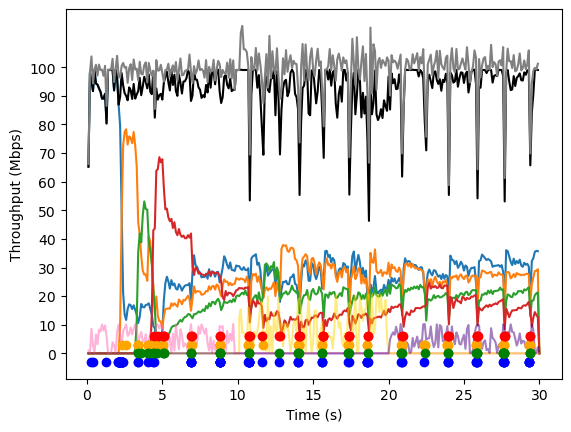

median ratio: 1.9850065340266463


([93.351168,
  93.6535296,
  95.4010368,
  93.8297088,
  94.4891904,
  93.553536,
  94.303488,
  93.7868544,
  93.5035392,
  94.2463488,
  94.2463488],
 [1.7082393554667,
  2.673943620892361,
  2.2835314091680816,
  1.8677058725336364,
  1.9393375511723112,
  2.0568354393207144,
  1.8004223864836326,
  2.1781462585034013,
  1.6631998847929357,
  1.9850065340266463,
  1.9850065340266463],
 [1.9514844315713251,
  3.2037213740458017,
  2.4035087719298245,
  2.49535747446611,
  2.024242424242424,
  2.106270358306189,
  2.2352707006369426,
  2.2983521248915872,
  2.1624345022168483,
  2.141653290529695,
  2.141653290529695],
 [92.61333333333333,
  90.57776,
  93.32190476190476,
  90.6961852631579,
  90.68227555555555,
  91.76304761904761,
  91.07210105263158,
  93.29454222222222,
  93.40693333333333,
  92.708576,
  92.708576])

In [4]:
iteration = 1
taxConstant = "10000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.70066944
median fairness: 1.931645092818969
max fairness: 2.158163301494231


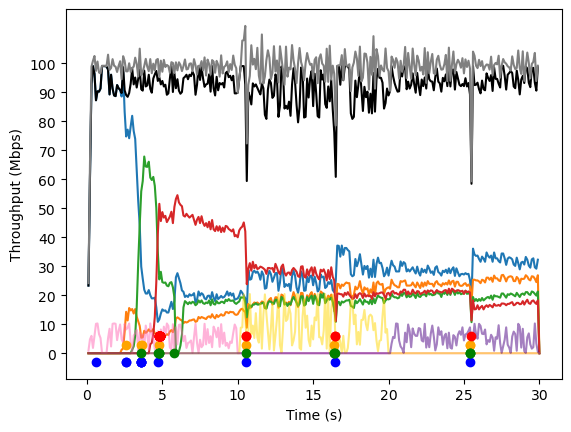

median ratio: 1.8409114075500008


([93.1035648,
  93.3368832,
  93.7582848,
  93.5844864,
  94.0249344,
  93.7225728,
  93.351168,
  93.6940032,
  94.5439488,
  93.886848,
  93.5844864],
 [1.682842151573766,
  2.903837765050749,
  2.702284336995714,
  1.8409114075500008,
  2.5582426440951225,
  1.6213991769547325,
  2.0223787780879374,
  2.261974177426072,
  1.5237398697265772,
  1.419124218051832,
  1.8409114075500008],
 [1.8578412937194433,
  3.4595719381688466,
  3.3816641753861485,
  2.0430147058823525,
  2.907679033649698,
  1.7322834645669292,
  2.2733118971061095,
  2.5026785714285715,
  1.7376074025115664,
  1.4920060331825038,
  2.0430147058823525],
 [88.26553904761904,
  90.48761904761905,
  89.381408,
  88.81486545454545,
  88.75870476190477,
  88.64533333333334,
  87.61368888888889,
  89.87540363636364,
  88.79216,
  87.42571789473685,
  88.81486545454545])

In [5]:
iteration = 1
taxConstant = "50000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.8249472
median fairness: 1.748461139018131
max fairness: 1.91722886150467


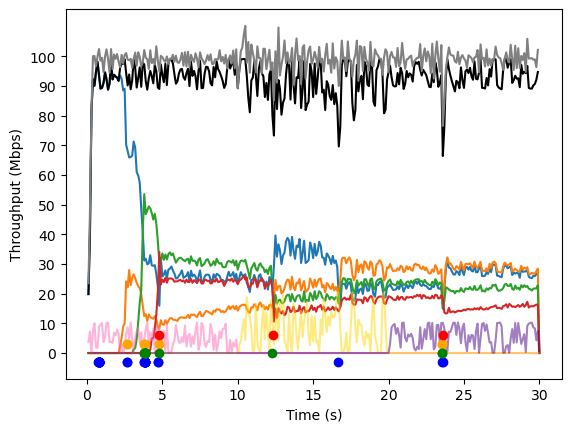

median ratio: 1.7940486827293425


([93.32736,
  93.8249472,
  93.3916416,
  93.5559168,
  93.9416064,
  93.5582976,
  95.0605824,
  93.9487488,
  93.8225664,
  93.8178048,
  93.5582976],
 [2.51225037850741,
  1.0828830692798235,
  1.5599768309159385,
  2.161507544443324,
  1.7028735953069194,
  1.7940486827293425,
  1.3606365384732055,
  2.2750439221689334,
  1.8874401337081959,
  1.3156971290002835,
  1.7940486827293425],
 [3.1317398554752645,
  1.1767388825541618,
  1.6659939455095865,
  2.4592976855546684,
  1.8754119973632168,
  1.9590457256461231,
  1.4310892805547533,
  2.54862535904801,
  2.1104,
  1.3786965259833477,
  1.9590457256461231],
 [87.83472761904761,
  85.494752,
  85.226912,
  87.09365894736843,
  86.19182222222223,
  85.92329600000001,
  87.50787555555556,
  87.53248,
  85.90544,
  86.09923555555555,
  85.92329600000001])

In [6]:
iteration = 1
taxConstant = "70000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.96112896
median fairness: 1.5802878694708857
max fairness: 1.6143505021056042


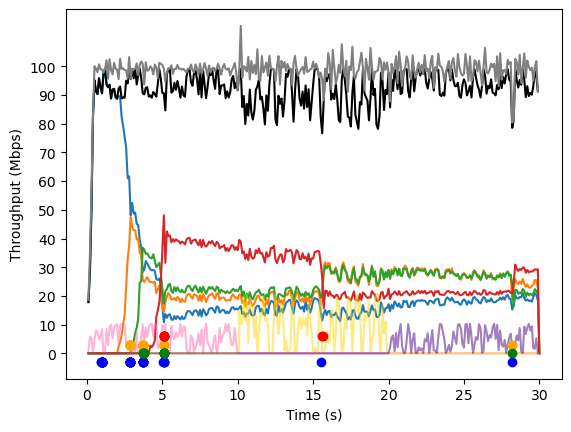

median ratio: 1.4611041405269765


([94.6915584,
  93.898752,
  94.732032,
  92.625024,
  93.0988032,
  94.8320256,
  93.9273216,
  94.4915712,
  94.0416,
  93.2726016,
  93.2726016],
 [1.346386781433221,
  1.6994715984147952,
  3.031798245614035,
  1.7818571844494862,
  1.7433427540131816,
  1.2615435157073076,
  2.2094479915656033,
  1.2536074477112993,
  1.3086382459728712,
  1.4611041405269765,
  1.4611041405269765],
 [1.4011194029850746,
  1.7538062844185294,
  3.257971014492754,
  2.185973207249803,
  1.7621206836414371,
  1.2920747996438111,
  2.3538598839803657,
  1.2848013337038067,
  1.3318398207784936,
  1.474894719792679,
  1.474894719792679],
 [82.58755555555555,
  85.268576,
  84.46574222222222,
  83.542496,
  83.02403555555556,
  84.30887619047618,
  82.85207578947369,
  85.4992761904762,
  81.9989688888889,
  82.87087157894737,
  82.87087157894737])

In [7]:
iteration = 1
taxConstant = "100000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.13635584
median fairness: 1.5433121544596253
max fairness: 1.5916047178986712


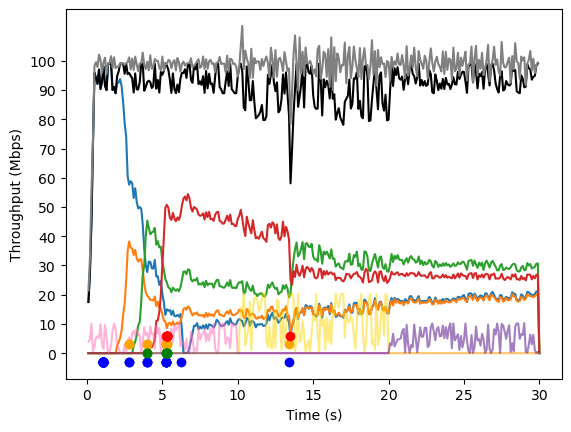

median ratio: 1.5642165190696


([94.7034624,
  94.2653952,
  92.8583424,
  93.0392832,
  94.75584,
  94.48204799999999,
  94.2011136,
  93.9011328,
  94.7034624,
  94.4534784,
  94.4534784],
 [1.2402523725684564,
  1.2722878937268582,
  1.609102569618483,
  1.5224077898496504,
  1.6849517631934041,
  1.2614007320648946,
  2.5882286060607234,
  1.845558388175466,
  1.217693474057544,
  1.5642165190696,
  1.5642165190696],
 [1.257495590828924,
  1.2995805871779509,
  1.6935914552736984,
  1.5632599408478476,
  1.7801659125188538,
  1.2880184331797233,
  2.810672139558748,
  2.125748502994012,
  1.2519188596491229,
  1.6199494949494948,
  1.6199494949494948],
 [84.52995047619048,
  83.030624,
  81.9989688888889,
  84.18416761904761,
  82.78064,
  82.26940631578947,
  83.67966476190476,
  82.15568,
  82.63384888888889,
  82.74556631578947,
  82.74556631578947])

In [8]:
iteration = 1
taxConstant = "110000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.20754176
median fairness: 1.464720228264385
max fairness: 1.5192309372090804


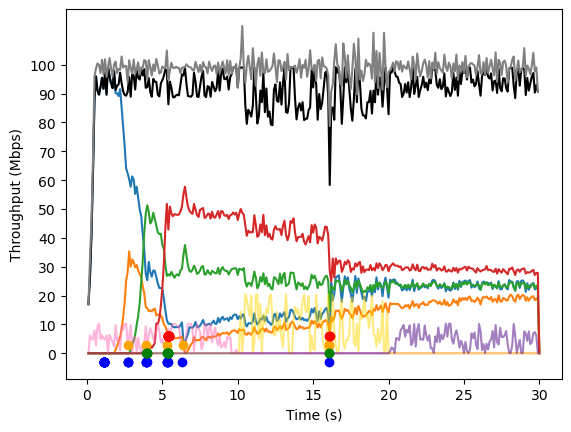

median ratio: 1.4916068811187242


([94.541568,
  94.9129728,
  93.9130368,
  93.6463872,
  92.9035776,
  95.3415168,
  94.0796928,
  94.2153984,
  94.3415808,
  94.1796864,
  94.9129728],
 [1.3815691855044387,
  1.4916068811187242,
  1.363640686496847,
  1.2103541235359145,
  1.6110753670678308,
  1.4378335754100455,
  2.362268518518518,
  1.3931555701497484,
  1.6197621100430126,
  2.5073963553312772,
  1.4916068811187242],
 [1.4266221952698606,
  1.5516036837091143,
  1.4032111481369283,
  1.2385726924211147,
  1.9416733708769105,
  1.4868581907090463,
  2.5101434933201383,
  1.4317389927146025,
  1.7104622871046231,
  2.7919375812743823,
  1.5516036837091143],
 [81.50096,
  80.9077688888889,
  81.53010526315789,
  82.64798476190477,
  82.48304,
  82.33259636363637,
  82.863968,
  81.50296888888889,
  82.98896,
  83.32821333333334,
  80.9077688888889])

In [9]:
iteration = 1
taxConstant = "120000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.60900864
median fairness: 2.6652956933013208
max fairness: 2.8695980899323517


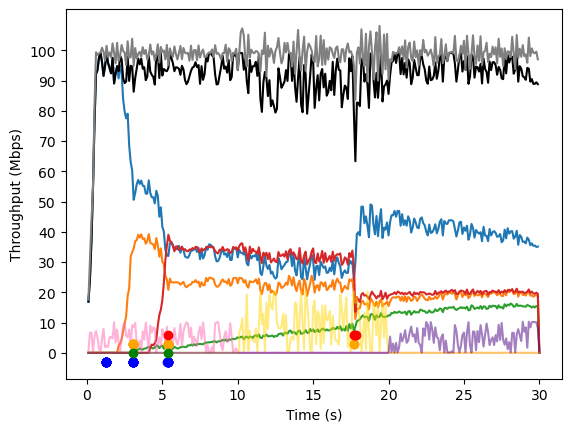

median ratio: 2.459732547823108


([93.9368448,
  93.4749696,
  93.9725568,
  93.5630592,
  93.6297216,
  93.3559296,
  92.9869056,
  93.1416576,
  93.4749696,
  94.553472,
  93.4749696],
 [1.5953694634154174,
  2.459732547823108,
  3.158058771148709,
  2.870858838779534,
  1.642675581543072,
  2.9547373461830713,
  2.9131289953897106,
  3.2573919893949688,
  1.4137870983166523,
  1.2316500836418067,
  2.459732547823108],
 [1.652370203160271,
  2.6561878233187426,
  3.3254079254079256,
  3.0830083565459607,
  1.739583333333333,
  3.2311916529379463,
  3.2406281661600813,
  3.584511370620774,
  1.4540958268933541,
  1.26664736537348,
  2.6561878233187426],
 [82.80334545454545,
  81.44144,
  81.21383619047619,
  80.167712,
  82.82371047619047,
  80.85345684210526,
  81.88839619047619,
  79.40654222222223,
  80.661728,
  81.00409904761905,
  81.44144])

In [10]:
iteration = 1
taxConstant = "135000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.9273216
median fairness: 2.815382704002185
max fairness: 3.3308976579273724


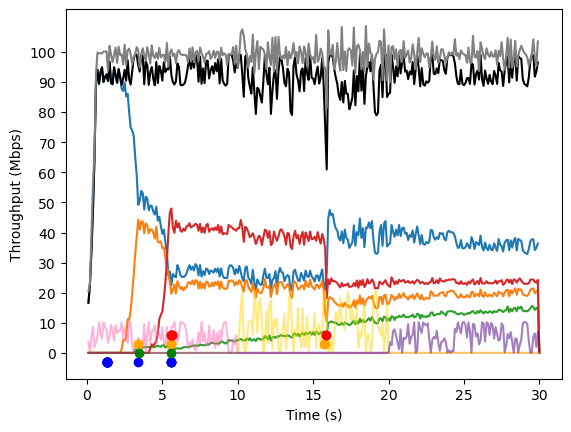

median ratio: 2.491486877550246


([94.22015999999999,
  93.11070720000001,
  94.9129728,
  93.5559168,
  94.3106304,
  93.3130752,
  93.3083136,
  94.3915776,
  93.7844736,
  94.3653888,
  93.11070720000001],
 [3.492147450480784,
  2.491486877550246,
  1.969031429917985,
  3.1392785304541246,
  2.4571858197329997,
  3.4235448117026825,
  1.2510888801173956,
  3.3324235807860263,
  1.9994001212106627,
  3.789165715502876,
  2.491486877550246],
 [3.7815884476534305,
  2.661340434975588,
  2.075573065902579,
  3.432188065099458,
  2.6246660730187,
  3.8127313101406366,
  1.2786795048143054,
  3.6485862665897293,
  3.229607250755287,
  4.201468189233279,
  2.661340434975588],
 [79.5642819047619,
  79.5513890909091,
  79.33099789473684,
  79.19942736842106,
  79.899872,
  78.22275555555555,
  80.8340419047619,
  78.57290105263158,
  80.86082909090909,
  78.33482105263158,
  79.5513890909091])

In [11]:
iteration = 1
taxConstant = "150000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.1082624
median fairness: 3.2507746665624904
max fairness: 3.477106383912891


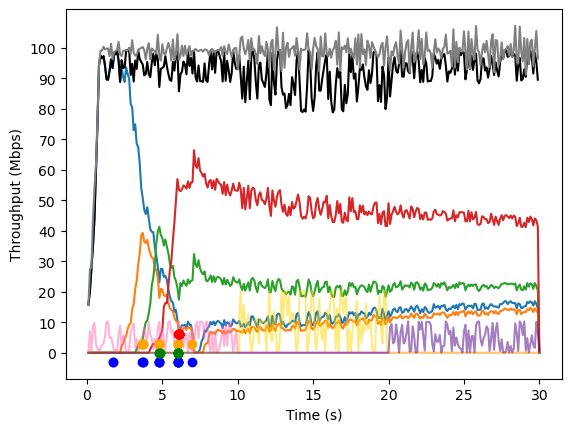

median ratio: 3.1485156252598117


([93.541632,
  94.2392064,
  94.5272832,
  93.6678144,
  94.10112,
  93.5344896,
  94.0201728,
  94.6867968,
  94.6320384,
  94.1320704,
  94.5272832],
 [3.598394835006101,
  4.009272479996859,
  3.1485156252598117,
  3.1344612781934584,
  3.04920634920635,
  1.5838852097130243,
  4.7922237735502735,
  3.353033707865169,
  2.865373961218837,
  3.480484635465579,
  3.1485156252598117],
 [3.9205495818399045,
  4.335628227194492,
  3.3748858447488583,
  3.32069970845481,
  3.24349750968456,
  1.6231593038821954,
  5.154088050314466,
  3.579326923076923,
  3.0807600950118768,
  3.770419426048565,
  3.3748858447488583],
 [75.435872,
  74.24986947368421,
  77.18141090909091,
  74.263328,
  76.56456727272727,
  71.91363555555556,
  74.721632,
  77.18682181818181,
  74.703776,
  76.07758545454546,
  77.18141090909091])

In [12]:
iteration = 1
taxConstant = "200000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.86042112
median fairness: 6.113293336415307
max fairness: 6.696138342944568


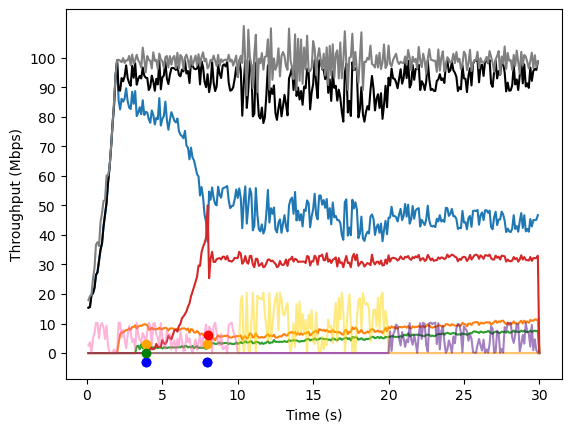

median ratio: 6.024358774116002


([93.291648,
  94.0392192,
  93.56782079999999,
  93.7749504,
  94.446336,
  93.8939904,
  93.9987456,
  94.6296576,
  93.6678144,
  93.2940288,
  94.446336],
 [4.786549955531436,
  6.202227898714613,
  7.913366778795963,
  6.9871335473760645,
  6.024358774116002,
  5.937859994514369,
  8.036866739198345,
  8.682017543859649,
  5.807986312746255,
  3.530345211581292,
  6.024358774116002],
 [5.019732205778717,
  6.746587030716722,
  8.815602836879433,
  7.755056179775281,
  6.645689655172414,
  6.4591666666666665,
  8.862108922363847,
  9.687904967602591,
  6.291946308724832,
  3.7905484247374566,
  6.645689655172414],
 [43.88213894736842,
  46.253216,
  48.85196190476191,
  43.76936421052632,
  46.77104,
  48.319116190476194,
  46.491296,
  48.40414476190476,
  46.431776,
  41.24099555555556,
  46.77104])

In [13]:
iteration = 1
taxConstant = "500000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

In [14]:
iqr_throughput = []
iqr_median_fairness = []
iqr_max_fairness = []
iqr_time = []
iqr_util_first2 = []

q25_throughput = []
q25_median_fairness = []
q25_max_fairness = []
q25_time = []
q25_util_first2 = []

q75_throughput = []
q75_median_fairness = []
q75_max_fairness = []
q75_time = []
q75_util_first2 = []

q50_throughput = []
q50_median_fairness = []
q50_max_fairness = []
q50_time = []
q50_util_first2 = []

throughput_upper_error = []
median_fairness_upper_error = []
max_fairness_upper_error = []
util_first2_upper_error = []

throughput_lower_error = []
median_fairness_lower_error = []
max_fairness_lower_error = []
util_first2_lower_error = []


print(len(labels))

new_labels = []
for index in range(0, len(labels)):
#     new_labels.append(str(int(labels[index]) / 1000000000))
    new_labels.append(labels[index])
    
print(new_labels)
    
df_throughput = pd.DataFrame({label: result for label, result in zip(labels, all_throughput_results)})

df_median_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_median_fairness_results)})

df_max_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_max_fairness_results)})

df_util_first2 = pd.DataFrame({label: result for label, result in zip(labels, all_first2_results)})


#calculate interquartile range of values of throughput, fairness, time and store in iqr array
for value in labels:
    q75, q50, q25 = np.percentile(df_throughput[str(value)], [75,50, 25])
    iqr = q75 - q25
    iqr_throughput.append(iqr)
    q25_throughput.append(q25)
    q50_throughput.append(q50)
    q75_throughput.append(q75)

    q75, q50, q25 = np.percentile(df_median_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_median_fairness.append(iqr)
    q25_median_fairness.append(q25)
    q50_median_fairness.append(q50)
    q75_median_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_max_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_max_fairness.append(iqr)
    q25_max_fairness.append(q25)
    q50_max_fairness.append(q50)
    q75_max_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_util_first2[value], [75,50, 25])
    iqr = q75 - q25
    iqr_util_first2.append(iqr)
    q25_util_first2.append(q25)
    q50_util_first2.append(q50)
    q75_util_first2.append(q75)
    
for value in labels:
    throughput_upper_error.append(q75_throughput[labels.index(value)] - q50_throughput[labels.index(value)])
    throughput_lower_error.append(q50_throughput[labels.index(value)] - q25_throughput[labels.index(value)])
    
    median_fairness_upper_error.append(q75_median_fairness[labels.index(value)] - q50_median_fairness[labels.index(value)])
    median_fairness_lower_error.append(q50_median_fairness[labels.index(value)] - q25_median_fairness[labels.index(value)])

    max_fairness_upper_error.append(q75_max_fairness[labels.index(value)] - q50_max_fairness[labels.index(value)])
    max_fairness_lower_error.append(q50_max_fairness[labels.index(value)] - q25_max_fairness[labels.index(value)])
    
    util_first2_upper_error.append(q75_util_first2[labels.index(value)] - q50_util_first2[labels.index(value)])
    util_first2_lower_error.append(q50_util_first2[labels.index(value)] - q25_util_first2[labels.index(value)])

10
['10000', '50000', '70000', '100000', '110000', '120000', '135000', '150000', '200000', '500000']


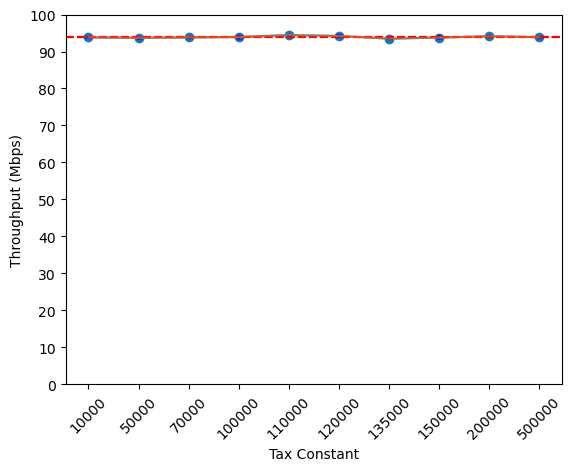

<Figure size 550x200 with 0 Axes>

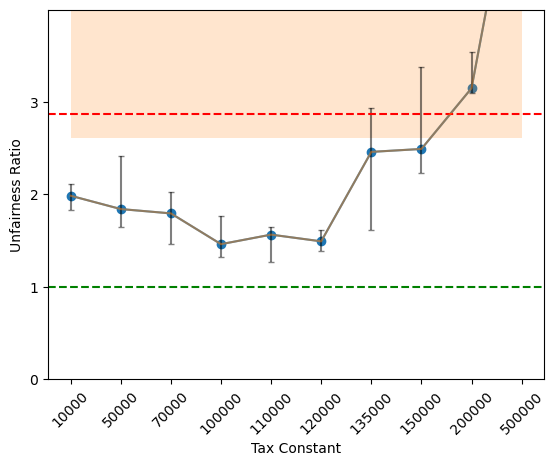

<Figure size 550x200 with 0 Axes>

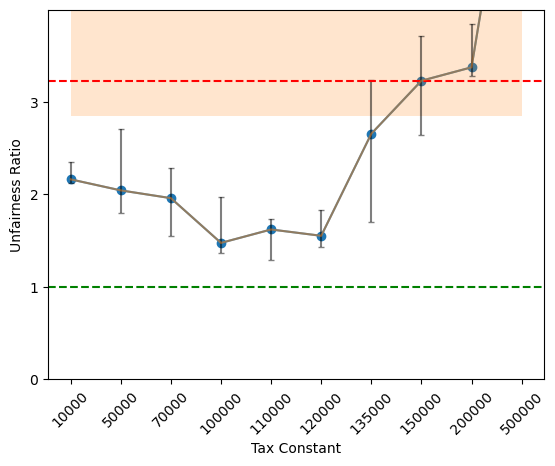

<Figure size 550x200 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
######################### Tax Constant vs Throughput  ###############
plt.xlabel('Tax Constant')
plt.ylabel('Throughput (Mbps)')
plt.scatter(new_labels, q50_throughput)
# # plt.scatter(new_labels, q50_util_first2)
plt.plot(new_labels, q50_throughput)
# plt.plot(new_labels, q50_util_first2)
plt.errorbar(new_labels, q50_throughput, yerr=[throughput_lower_error, throughput_upper_error], alpha=0.5, ecolor='blue', capsize=2)
# plt.errorbar(new_labels, q50_util_first2, yerr=[util_first2_lower_error, util_first2_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
yticks = np.arange(0, 110, 10)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Median Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_median_fairness)
plt.plot(new_labels, q50_median_fairness)
plt.errorbar(new_labels, q50_median_fairness, yerr=[median_fairness_lower_error, median_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 4.11361720933764, 2.61468217548715, alpha=0.2)
yticks = np.arange(0, 4, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 4)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Max Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_max_fairness)
plt.plot(new_labels, q50_max_fairness)
plt.errorbar(new_labels, q50_max_fairness, yerr=[max_fairness_lower_error, max_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_max_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 4.699445553396953, 2.847744529609219, alpha=0.2)
yticks = np.arange(0, 4, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 4)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()